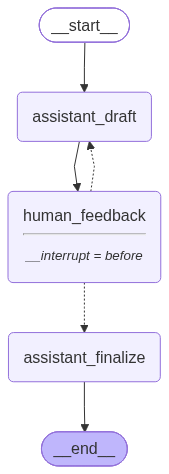

In [1]:
from typing import Literal, Optional
from langgraph.graph import StateGraph, MessagesState, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
from pprint import pprint
import os
from dotenv import load_dotenv

# Get Env Vars
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# --- Model Definition ---
# Groq API key configured in .env file
model = ChatGroq(model="llama-3.1-8b-instant", api_key=GROQ_API_KEY)


# --- Graph State Definition ---
class DraftReviewState(MessagesState):
    human_request: str
    human_comment: Optional[str]
    status: Literal["approved", "feedback"]
    assistant_response: str


# --- Graph Nodes Definition ---
def assistant_draft(state: DraftReviewState) -> DraftReviewState:
    user_message = HumanMessage(content=state["human_request"])
    status = state.get("status", "approved")

    if (status == "feedback" and state.get("human_comment")):
        human_comment = HumanMessage(content=state["human_comment"])

        system_message = SystemMessage(content=(f"""
        You are an AI assistant revising your previous draft. Carefully review the human's 
        feedback and update your reply accordingly. Address all comments, corrections, 
        or suggestions provided by the human. Ensure your revised response fully 
        integrates the feedback, improves clarity, and resolves any issues raised.
        """))

        messages = [user_message] + state["messages"] + [system_message, human_comment]
        all_messages = state["messages"] + [human_comment]

    else:
        system_message = SystemMessage(content=("""
        You are an AI assistant. Your goal is to fully understand and fulfill the user's 
        request by preparing a relevant, clear, and helpful draft reply. Focus on addressing 
        the user's needs directly and comprehensively. 
        Do not reference any previous human feedback at this stage.
        """))
        messages = [system_message, user_message]
        all_messages = state["messages"]
    
    response = model.invoke(messages)

    all_messages = all_messages + [response]

    return {
        **state,
        "messages": all_messages,
        "assistant_response": response.content
    }


def human_feedback(state: DraftReviewState):
    pass


def assistant_finalize(state: DraftReviewState) -> DraftReviewState:
    system_message = """
    You are an AI assistant. The user has approved your draft. Carefully 
    review your reply and make any final improvements to clarity, tone, and 
    completeness. Ensure the response is polished, professional, and ready 
    to be delivered as the final answer.
    """
    messages = [system_message] + state["messages"]
    response = model.invoke(messages)

    all_messages = state['messages'] + [response]

    return {
        **state,
        "messages": all_messages,
        "assistant_response": response.content
    }
    

# --- Router Function ---
def feedback_router(state: DraftReviewState) -> str:
    if state['status'] == 'approved':
        return 'assistant_finalize'
    else:
        return 'assistant_draft'

# --- Graph Construction ---
builder = StateGraph(DraftReviewState)

# builder.add_node('start', start_node)
builder.add_node('assistant_draft', assistant_draft)
builder.add_node('human_feedback', human_feedback)
builder.add_node('assistant_finalize', assistant_finalize)

builder.add_edge(START, 'assistant_draft')
builder.add_edge('assistant_draft', 'human_feedback')
builder.add_conditional_edges('human_feedback', feedback_router, {'assistant_finalize': 'assistant_finalize', 'assistant_draft': 'assistant_draft'})
builder.add_edge('assistant_finalize', END)

memory = MemorySaver()
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
config = {"configurable": {"thread_id": "1"}}

result = graph.invoke({"human_request": "Explain what is HITL"}, config)
result

{'messages': [AIMessage(content='HITL stands for Human-in-the-Loop. It is a concept used in various fields, including artificial intelligence, machine learning, and cybersecurity, to describe a system that involves humans in the decision-making process or loop of an automated process.\n\nIn a HITL system, a human is integrated into the loop of an automated process to provide input, validate decisions, or correct errors made by the automated system. This human involvement is typically used to ensure that the automated system is making accurate or appropriate decisions, and to provide a layer of oversight and accountability.\n\nHere are some common applications of HITL:\n\n1. **AI and Machine Learning**: In AI and machine learning, HITL is used to validate the decisions made by the models. For example, in content moderation, a human is used to review and validate the decisions made by an AI-powered moderation system.\n2. **Cybersecurity**: In cybersecurity, HITL is used to detect and res

In [6]:
state = graph.get_state(config)
pprint(state)

StateSnapshot(values={'messages': [AIMessage(content='HITL stands for Human-in-the-Loop. It is a concept used in various fields, including artificial intelligence, machine learning, and cybersecurity, to describe a system that involves humans in the decision-making process or loop of an automated process.\n\nIn a HITL system, a human is integrated into the loop of an automated process to provide input, validate decisions, or correct errors made by the automated system. This human involvement is typically used to ensure that the automated system is making accurate or appropriate decisions, and to provide a layer of oversight and accountability.\n\nHere are some common applications of HITL:\n\n1. **AI and Machine Learning**: In AI and machine learning, HITL is used to validate the decisions made by the models. For example, in content moderation, a human is used to review and validate the decisions made by an AI-powered moderation system.\n2. **Cybersecurity**: In cybersecurity, HITL is u

In [7]:
graph.update_state(config, {
    "status": "feedback",
    "human_comment": "Make your answer only one sentence short!"
})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f186d77-0360-6c86-8002-b05364740321'}}

In [8]:
resumed_result = graph.invoke(None, config)
resumed_result

{'messages': [AIMessage(content='HITL stands for Human-in-the-Loop. It is a concept used in various fields, including artificial intelligence, machine learning, and cybersecurity, to describe a system that involves humans in the decision-making process or loop of an automated process.\n\nIn a HITL system, a human is integrated into the loop of an automated process to provide input, validate decisions, or correct errors made by the automated system. This human involvement is typically used to ensure that the automated system is making accurate or appropriate decisions, and to provide a layer of oversight and accountability.\n\nHere are some common applications of HITL:\n\n1. **AI and Machine Learning**: In AI and machine learning, HITL is used to validate the decisions made by the models. For example, in content moderation, a human is used to review and validate the decisions made by an AI-powered moderation system.\n2. **Cybersecurity**: In cybersecurity, HITL is used to detect and res

In [9]:
graph.update_state(config, {
    "status": "approved"
})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f186d77-325a-602d-8005-8e3a3b5783ad'}}

In [10]:
resumed_result = graph.invoke(None, config)
resumed_result

{'messages': [AIMessage(content='HITL stands for Human-in-the-Loop. It is a concept used in various fields, including artificial intelligence, machine learning, and cybersecurity, to describe a system that involves humans in the decision-making process or loop of an automated process.\n\nIn a HITL system, a human is integrated into the loop of an automated process to provide input, validate decisions, or correct errors made by the automated system. This human involvement is typically used to ensure that the automated system is making accurate or appropriate decisions, and to provide a layer of oversight and accountability.\n\nHere are some common applications of HITL:\n\n1. **AI and Machine Learning**: In AI and machine learning, HITL is used to validate the decisions made by the models. For example, in content moderation, a human is used to review and validate the decisions made by an AI-powered moderation system.\n2. **Cybersecurity**: In cybersecurity, HITL is used to detect and res

In [11]:
state = graph.get_state(config)
pprint(state)

StateSnapshot(values={'messages': [AIMessage(content='HITL stands for Human-in-the-Loop. It is a concept used in various fields, including artificial intelligence, machine learning, and cybersecurity, to describe a system that involves humans in the decision-making process or loop of an automated process.\n\nIn a HITL system, a human is integrated into the loop of an automated process to provide input, validate decisions, or correct errors made by the automated system. This human involvement is typically used to ensure that the automated system is making accurate or appropriate decisions, and to provide a layer of oversight and accountability.\n\nHere are some common applications of HITL:\n\n1. **AI and Machine Learning**: In AI and machine learning, HITL is used to validate the decisions made by the models. For example, in content moderation, a human is used to review and validate the decisions made by an AI-powered moderation system.\n2. **Cybersecurity**: In cybersecurity, HITL is u